In [ ]:
import pandas as pd
from pathlib import Path

from aml_detection.splitting import load_split
from aml_detection.baseline import baseline_report, RULES

val = load_split("val")
report = baseline_report(val)

for name, table in report.items():
    print(f"\n=== {name} ===")
    print(table.round(4).to_string())



ModuleNotFoundError: No module named 'aml_detection'

In [2]:
import sys, subprocess
print("EXECUTABLE:", sys.executable)
print()
print(subprocess.run([sys.executable, "-m", "pip", "show", "aml_detection"],
                     capture_output=True, text=True).stdout)
print("PATH ENTRIES:")
for p in sys.path:
    print(" ", p)

EXECUTABLE: /Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection/.venv/bin/python

Name: aml_detection
Version: 0.0.1
Summary: Ml pipeline for detecting money laundering topologies
Home-page: 
Author: Ruturaj Desai
Author-email: 
License: 
Location: /Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection/.venv/lib/python3.11/site-packages
Editable project location: /Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection
Requires: 
Required-by: 

PATH ENTRIES:
  /opt/homebrew/Cellar/python@3.11/3.11.16/Frameworks/Python.framework/Versions/3.11/lib/python311.zip
  /opt/homebrew/Cellar/python@3.11/3.11.16/Frameworks/Python.framework/Versions/3.11/lib/python3.11
  /opt/homebrew/Cellar/python@3.11/3.11.16/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload
  
  /Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection/.venv/lib/python3.11/site-packages


In [3]:
import sys
sys.path.insert(0, "/Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection")

In [4]:
import pandas as pd
from pathlib import Path

from aml_detection.splitting import load_split
from aml_detection.baseline import baseline_report, RULES

val = load_split("val")
report = baseline_report(val)

for name, table in report.items():
    print(f"\n=== {name} ===")
    print(table.round(4).to_string())

2026-08-17 19:16:36.399 | INFO     | aml_detection.config:<module>:11 - PROJ_ROOT path is: /Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection


2026-08-17 19:16:36.801 | INFO     | aml_detection.baseline:baseline_report:264 - Evaluating rules baseline on 954,954 rows

=== individual ===
                         fired  fired_pct  caught  precision  recall     lift
dormant_reactivation   16046.0     0.0168   259.0     0.0161  0.2396  14.2590
high_fanin             16061.0     0.0168   173.0     0.0108  0.1600   9.5155
high_risk_format      106760.0     0.1118   923.0     0.0086  0.8538   7.6375
structuring_band      340381.0     0.3564   853.0     0.0025  0.7891   2.2138
rapid_passthrough     160537.0     0.1681   378.0     0.0024  0.3497   2.0800
amount_spike          106113.0     0.1111   217.0     0.0020  0.2007   1.8065
business_hours        268180.0     0.2808   411.0     0.0015  0.3802   1.3539

=== combined ===
             alerts  alert_rate  caught  precision  recall     lift
>=1 rules  653643.0      0.6845  1076.0     0.0016  0.9954   1.4542
>=2 rules  270337.0      0.2831   984.0     0.0036  0.9103   3.2155
>=3 rules 

In [5]:
REPORTS = Path("reports")
REPORTS.mkdir(exist_ok=True)

for name, table in report.items():
    table.to_csv(REPORTS / f"baseline_{name}.csv")

In [6]:
from aml_detection import baseline

original = dict(baseline.RULES)
baseline.RULES.pop("business_hours")

print("without business_hours:")
print(baseline_report(val)["combined"].round(4).to_string())

baseline.RULES = original    # restore

without business_hours:
2026-08-17 19:16:56.885 | INFO     | aml_detection.baseline:baseline_report:264 - Evaluating rules baseline on 954,954 rows
             alerts  alert_rate  caught  precision  recall     lift
>=1 rules  541674.0      0.5672  1073.0     0.0020  0.9926   1.7499
>=2 rules  161359.0      0.1690   945.0     0.0059  0.8742   5.1736
>=3 rules   34389.0      0.0360   596.0     0.0173  0.5513  15.3103
>=4 rules    8218.0      0.0086   177.0     0.0215  0.1637  19.0267
>=5 rules     258.0      0.0003    12.0     0.0465  0.0111  41.0883
>=6 rules       0.0      0.0000     0.0        NaN  0.0000      NaN


baseline PR-AUC : 0.0126
random baseline : 0.0011   (a model with no skill)
lift over random: 11.1x


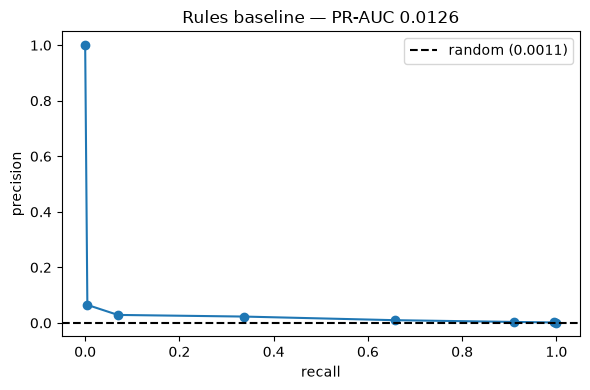

In [7]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

from aml_detection.baseline import rule_scores

scores = rule_scores(val)
y = val.is_laundering

pr_auc = average_precision_score(y, scores)
print(f"baseline PR-AUC : {pr_auc:.4f}")
print(f"random baseline : {y.mean():.4f}   (a model with no skill)")
print(f"lift over random: {pr_auc / y.mean():.1f}x")

precision, recall, _ = precision_recall_curve(y, scores)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker="o")
plt.axhline(y.mean(), ls="--", c="k", label=f"random ({y.mean():.4f})")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title(f"Rules baseline — PR-AUC {pr_auc:.4f}")
plt.legend(); plt.tight_layout(); plt.show()